# Comparing Different QEC Codes

## Imports

In [3]:
import pickle
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

## Extract Data

In [4]:
import glob

# Search specifically in the results folder
files = glob.glob("results/*.pkl")
all_data = {}

for f in files:
    with open(f, 'rb') as pkl:
        # Use only the filename (no folder name) as the label
        clean_name = os.path.basename(f)
        all_data[clean_name] = pickle.load(pkl)


print(f"Loaded {len(all_data)} files from the results folder.")

Loaded 2 files from the results folder.


## Comparing all by category

Loaded 8 files from the results folder.


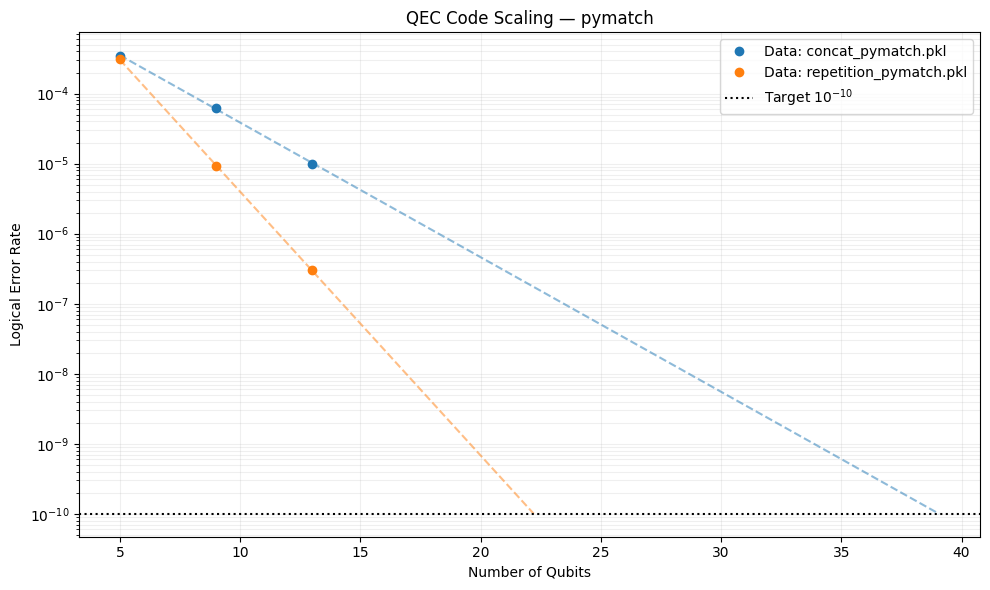

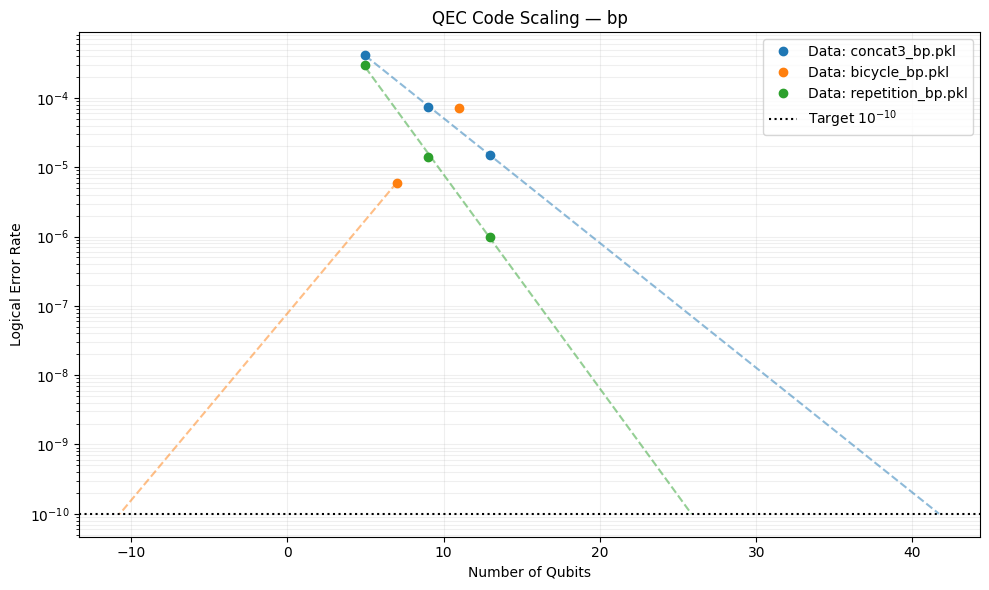

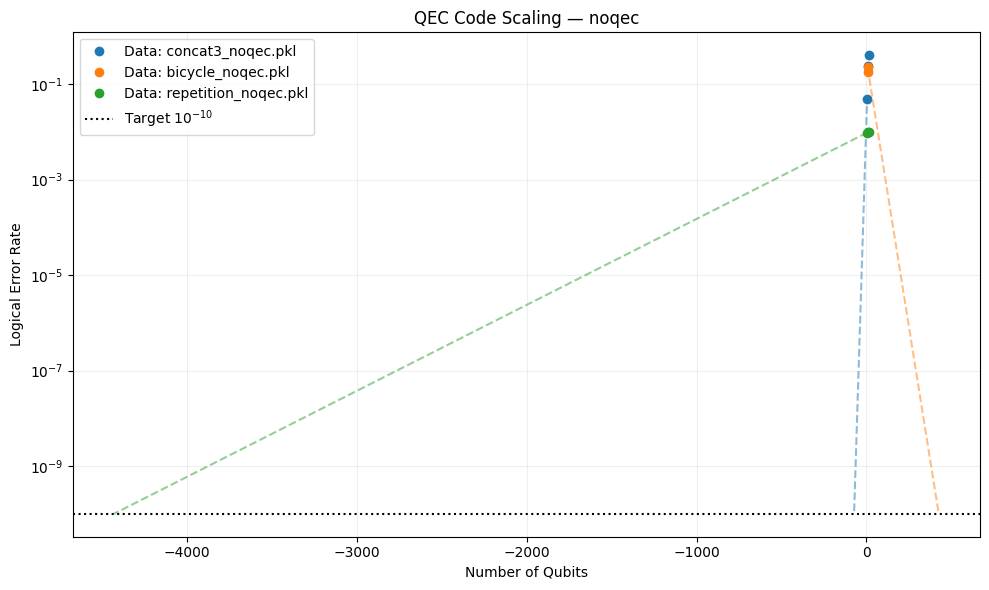

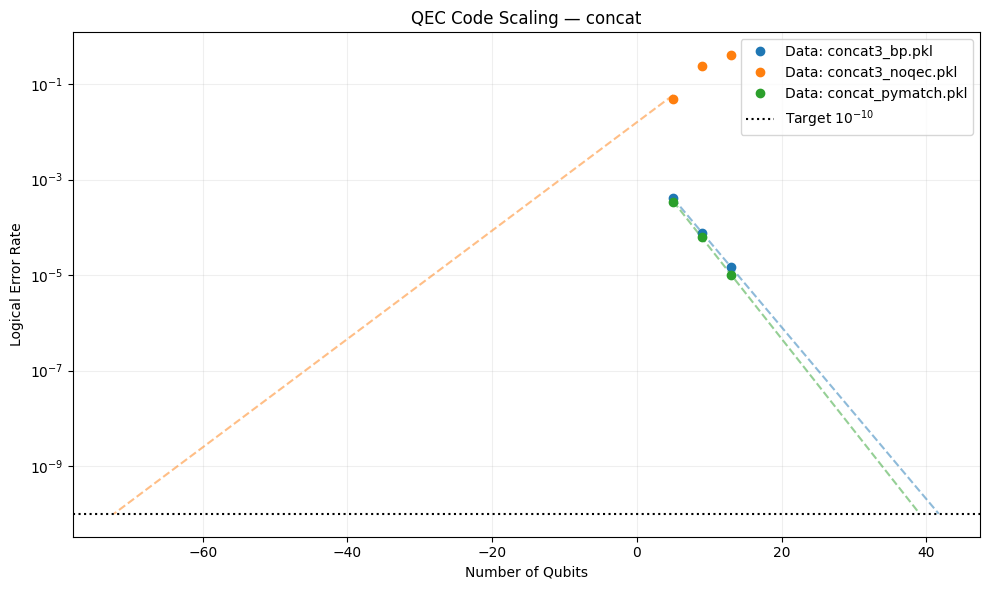

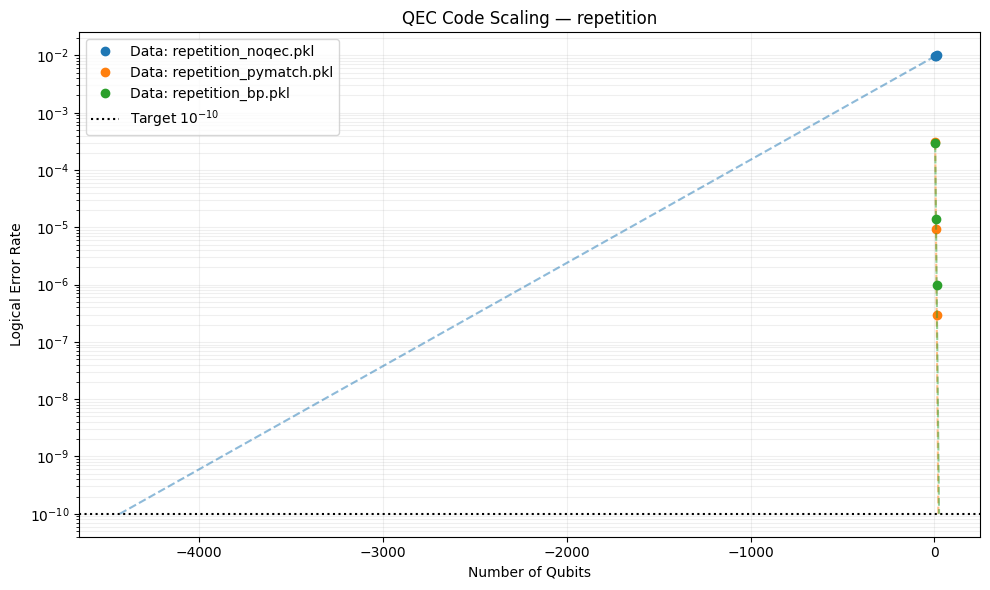

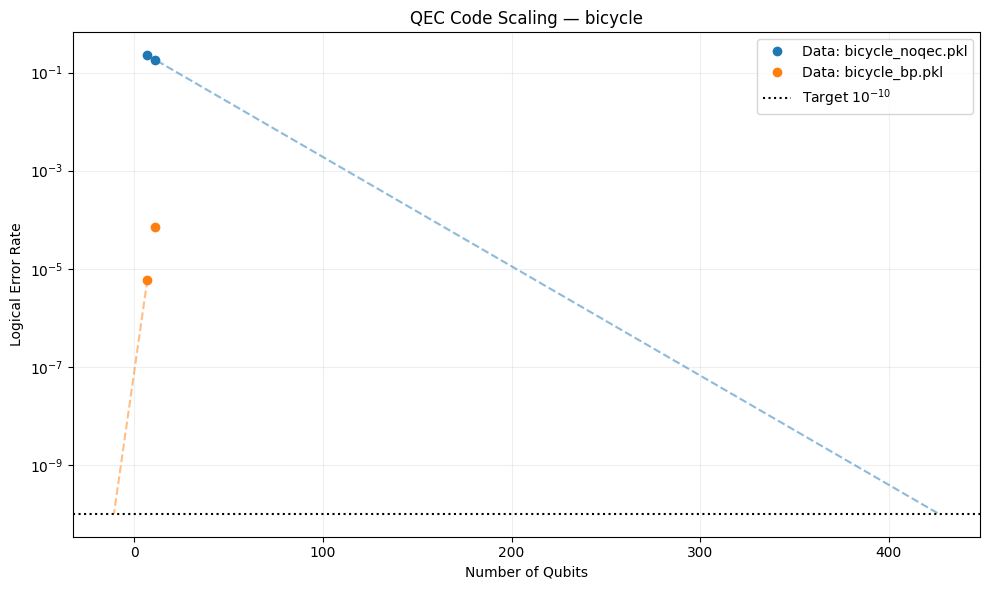

In [2]:
import glob
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load all files
files = glob.glob("results/*.pkl")
all_data = {}
for f in files:
    with open(f, 'rb') as pkl:
        clean_name = os.path.basename(f)
        all_data[clean_name] = pickle.load(pkl)
print(f"Loaded {len(all_data)} files from the results folder.")

# Define groups
groups = {
    'pymatch': [],
    'bp':         [],
    'noqec':      [],
    'concat':     [],
    'repetition': [],
    'bicycle':    [],
}

for label in all_data:
    label_lower = label.lower()
    for group_name in groups:
        if group_name in label_lower:
            groups[group_name].append(label)

# Plot one figure per group
for group_name, labels in groups.items():
    if not labels:
        continue  # skip empty groups

    fig, ax = plt.subplots(figsize=(10, 6))

    for label in labels:
        data = all_data[label]
        mask = np.array(data["raw_errors"]) > 0
        q = np.array(data["qubits"])[mask]
        p = np.array(data["logical_errors"])[mask]

        if len(q) < 2:
            continue  # need at least 2 points to fit

        line, = ax.semilogy(q, p, 'o', label=f'Data: {label}')

        d_vals = np.array(data["distances"])[mask]
        slope, intercept, _, _, _ = linregress(d_vals, np.log10(p))

        d_extrap = np.linspace(min(d_vals), data["required_d_1e10"], 100)
        q_extrap = 2 * d_extrap - 1
        p_extrap = 10**(slope * d_extrap + intercept)
        ax.semilogy(q_extrap, p_extrap, '--', color=line.get_color(), alpha=0.5)

    ax.axhline(1e-10, color='black', linestyle=':', label='Target $10^{-10}$')
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Logical Error Rate')
    ax.set_title(f'QEC Code Scaling — {group_name}')
    ax.legend()
    ax.grid(True, which="both", alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"results/plot_{group_name}.png", dpi=120)
    plt.show()

## Comparing all in 1 plot

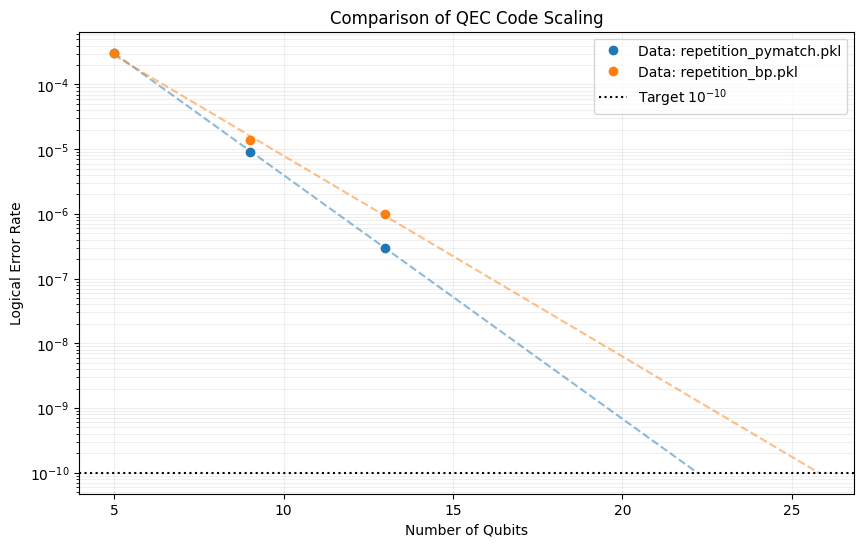

In [5]:

# --- Plot 1: All in one plot ---
plt.figure(figsize=(10, 6))
for label, data in all_data.items():
    # Only plot points where we actually measured errors
    mask = np.array(data["raw_errors"]) > 0
    q = np.array(data["qubits"])[mask]
    p = np.array(data["logical_errors"])[mask]
    
    line, = plt.semilogy(q, p, 'o', label=f'Data: {label}')
    
    # Add the extrapolation line for each
    d_vals = np.array(data["distances"])[mask]
    slope, intercept, _, _, _ = linregress(d_vals, np.log10(p))
    
    # Project line out to target
    d_extrap = np.linspace(min(d_vals), data["required_d_1e10"], 100)
    q_extrap = 2 * d_extrap - 1
    p_extrap = 10**(slope * d_extrap + intercept)
    plt.semilogy(q_extrap, p_extrap, '--', color=line.get_color(), alpha=0.5)

plt.axhline(1e-10, color='black', linestyle=':', label='Target $10^{-10}$')
plt.xlabel('Number of Qubits')
plt.ylabel('Logical Error Rate')
plt.title('Comparison of QEC Code Scaling')
plt.legend()
plt.grid(True, which="both", alpha=0.2)
plt.show()


## Comparing all in subplots

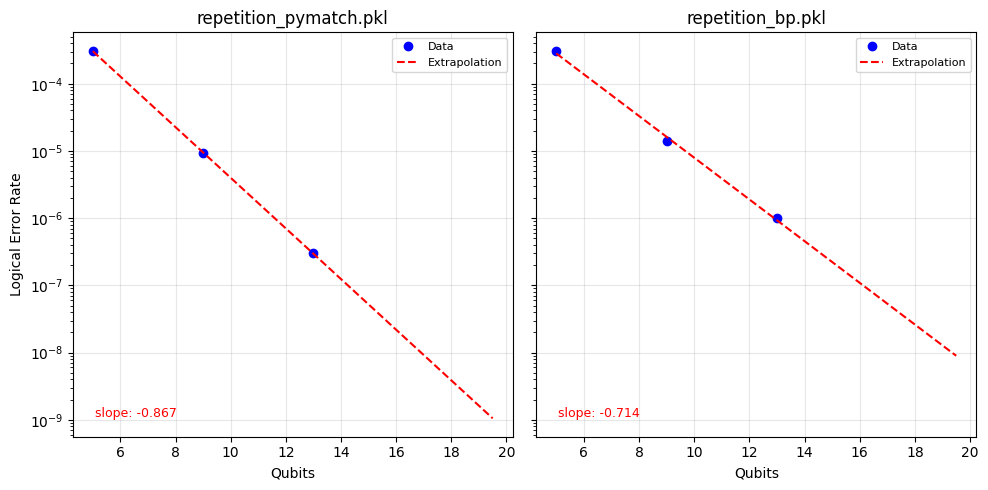

In [8]:
# --- Plot 2: Subplots with shared Y-axis ---
fig, axes = plt.subplots(1, len(files), figsize=(5*len(files), 5), sharey=True)
if len(files) == 1:
    axes = [axes]

for ax, (label, data) in zip(axes, all_data.items()):
    qubits = np.array(data["qubits"])
    logical_errors = np.array(data["logical_errors"])
    mask = np.array(data["raw_errors"]) > 0

    q_valid = qubits[mask]
    l_valid = logical_errors[mask]

    # Plot actual data points
    ax.semilogy(q_valid, l_valid, 'bo', label='Data')

    # Extrapolation in log space
    if len(q_valid) >= 2:
        log_l = np.log(l_valid)
        coeffs = np.polyfit(q_valid, log_l, 1)  # linear fit in log space
        q_extrap = np.linspace(q_valid.min(), q_valid.max() * 1.5, 200)
        l_extrap = np.exp(np.polyval(coeffs, q_extrap))
        ax.semilogy(q_extrap, l_extrap, 'r--', label='Extrapolation')

        # Annotate the slope (decay rate)
        slope = coeffs[0]
        ax.text(0.05, 0.05, f'slope: {slope:.3f}',
                transform=ax.transAxes, color='red', fontsize=9)

    ax.set_title(label)
    ax.set_xlabel('Qubits')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Logical Error Rate')
plt.tight_layout()
plt.show()

## Plotting number of required qubits

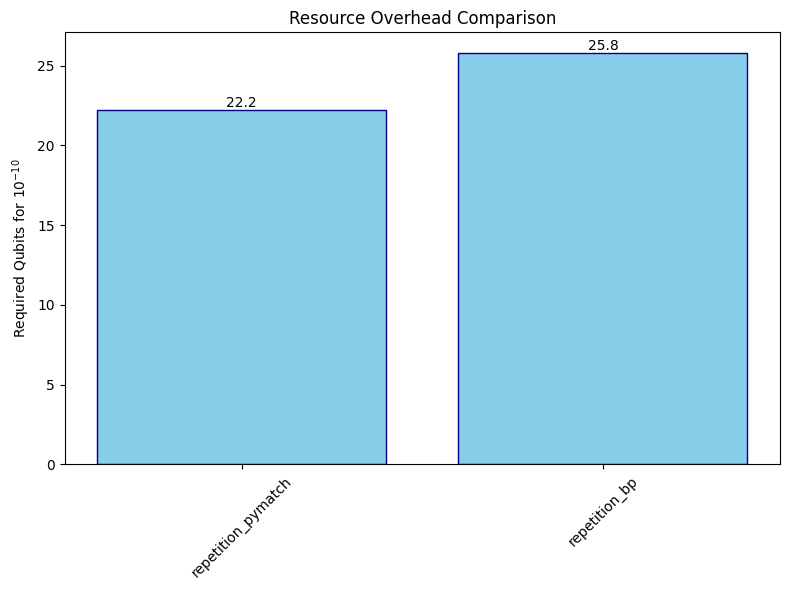

In [9]:
# --- Plot 3: Bar chart of required qubits ---
labels = [k.replace('.pkl', '') for k in all_data.keys()]
req_qubits = [data["required_qubits_1e10"] for data in all_data.values()]
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, req_qubits, color='skyblue', edgecolor='navy')
plt.ylabel('Required Qubits for $10^{-10}$')
plt.title('Resource Overhead Comparison')
plt.bar_label(bars, fmt='%.1f')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()